# CNN using Keras

In [1]:
import kagglehub
import os
import tensorflow as tf
from tensorflow import keras


### dataset is Chest X-Rays

In [2]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [3]:
import os
from tensorflow import keras

data_dir = os.path.join(path, "chest_xray")

img_height, img_width = 180, 180
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "train"),
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "val"),
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "test"),
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [4]:
# Normalize pixel values to [0,1]
normalization_layer = keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [5]:
# Simple CNN model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(2, activation='softmax')  # 2 classes: NORMAL, PNEUMONIA
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(train_ds, validation_data=val_ds, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8535 - loss: 0.7027 - val_accuracy: 0.9375 - val_loss: 0.3380
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9616 - loss: 0.1086 - val_accuracy: 0.8750 - val_loss: 0.2269
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.9565 - loss: 0.1114 - val_accuracy: 0.8750 - val_loss: 0.2579
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9865 - loss: 0.0388 - val_accuracy: 1.0000 - val_loss: 0.0974
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9926 - loss: 0.0273 - val_accuracy: 0.9375 - val_loss: 0.1074
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.8125 - val_loss: 0.3952
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 0.0505
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9964 - loss: 0.0099 - val_accu

In [6]:
# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 613ms/step - accuracy: 0.7427 - loss: 2.9939
Test Accuracy: 72.76%


In [7]:
predictions = model.predict(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 606ms/step


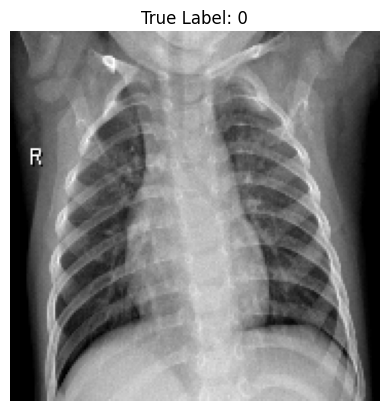

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Take one batch from test_ds
for images, labels in test_ds.take(1):
    # Pick one image from the batch
    idx = 14  # for example
    img = images[idx].numpy()
    label = labels[idx].numpy()

plt.imshow(img)  # no astype("uint8")
plt.title(f"True Label: {label}")
plt.axis("off")
plt.show()